# Análise Exploratória — Diabetes 130-US Hospitals

## 1. Setup e carregamento dos dados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
print(pd.__version__)

C:\Users\vvfpi\.conda\envs\dados\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.25.2 and <2.6.0 is required for this version of SciPy (detected version 1.24.3)
  from scipy.stats import gaussian_kde


2.3.3


## 2. Inspeção inicial e estrutura

In [3]:
df = pd.read_csv("../data/raw/diabetic_data.csv", na_values='?')


C:\Users\vvfpi\AppData\Local\Temp\ipykernel_12688\977781594.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/diabetic_data.csv", na_values='?')


In [4]:
df.columns[10]

'payer_code'

In [5]:
df["payer_code"].unique()[:30] 

array([nan, 'MC', 'MD', 'HM', 'UN', 'BC', 'SP', 'CP', 'SI', 'DM', 'CM',
       'CH', 'PO', 'WC', 'OT', 'OG', 'MP', 'FR'], dtype=object)

In [6]:
df.shape

(101766, 50)

In [7]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [8]:
df.dtypes.value_counts()

object    37
int64     13
Name: count, dtype: int64

**Inspeção inicial**

O dataset contém **101.766 encontros hospitalares** distribuídos por **50 variáveis**, das quais 13 são numéricas (`int64`) e 37 são categóricas (`object`). Esta predominância de variáveis categóricas vai exigir codificação cuidada na fase de pré-processamento ,em particular para variáveis de alta cardinalidade como os códigos de diagnóstico (`diag_1`, `diag_2`, `diag_3`).

A coluna `payer_code` (índice 10) gerou um `DtypeWarning` no carregamento por conter valores mistos, mas a inspeção dos valores únicos revela que se trata simplesmente de códigos categóricos curtos (e.g., `MC`, `MD`, `HM`, `BC`) que codificam o tipo de cobertura financeira do utente. Não constitui anomalia que justifique tratamento especial nesta fase.

A estrutura dos dados confirma a natureza relacional esperada: cada linha representa um **encontro hospitalar** identificado por `encounter_id`, ligado a um doente via `patient_nbr`. Múltiplos encontros do mesmo doente partilham o mesmo `patient_nbr`, o que justificará a estratégia de *split* por grupo (`GroupShuffleSplit`) na fase de modelação para prevenir *patient-level leakage*.

## 3. Variável-alvo: distribuição e binarização

In [9]:
df["readmitted"]

0          NO
1         >30
2          NO
3          NO
4          NO
         ... 
101761    >30
101762     NO
101763     NO
101764     NO
101765     NO
Name: readmitted, Length: 101766, dtype: object

In [10]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [11]:
(df["readmitted"].value_counts(normalize=True) * 100).round(2)

readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64

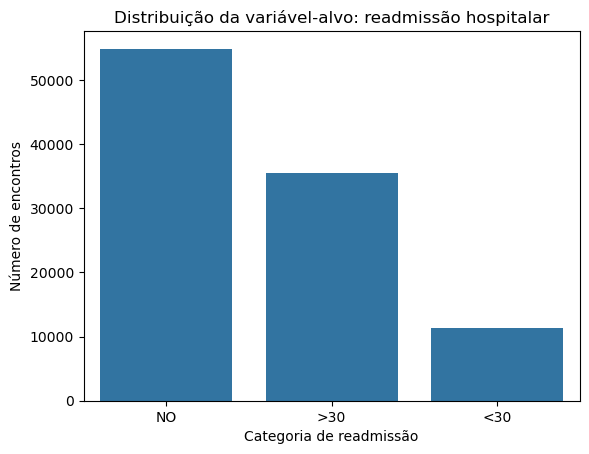

In [12]:
sns.countplot(data=df, x="readmitted", order=["NO", ">30", "<30"])
plt.title("Distribuição da variável-alvo: readmissão hospitalar")
plt.xlabel("Categoria de readmissão")
plt.ylabel("Número de encontros")
plt.show()

In [13]:
df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)
df["readmitted_30"]

0         0
1         0
2         0
3         0
4         0
         ..
101761    0
101762    0
101763    0
101764    0
101765    0
Name: readmitted_30, Length: 101766, dtype: int32

In [14]:
df["readmitted_30"].value_counts()

readmitted_30
0    90409
1    11357
Name: count, dtype: int64

In [15]:
(df["readmitted_30"].value_counts(normalize=True) * 100).round(2)

readmitted_30
0    88.84
1    11.16
Name: proportion, dtype: float64

In [16]:
prevalencia=(df["readmitted_30"].value_counts(normalize=True) * 100).round(2).iloc[1]
print(f"Prevalência da classe (<30 dias): {prevalencia}%")

Prevalência da classe (<30 dias): 11.16%


**Inspeção da variável-alvo**

A variável `readmitted` distribui-se em três categorias: **54.864 encontros sem readmissão (53.91%)**, **35.545 com readmissão tardia, >30 dias (34.93%)**, e **11.357 com readmissão precoce, <30 dias (11.16%)**.

A **binarização** adotada agrupa **"sem readmissão" e ">30 dias"** como **classe negativa (0)** e **"<30 dias"** como **classe positiva (1)**. Esta escolha tem fundamentação clínica e regulatória: a janela de 30 dias é a única em que a readmissão é razoavelmente atribuível à qualidade do internamento anterior e em que existe margem para intervenção preventiva à alta (reconciliação medicamentosa, *follow-up* precoce, programas de transição de cuidados). É também a métrica oficialmente monitorizada pelo CMS nos EUA e por sistemas de saúde europeus equivalentes.

A prevalência da classe positiva é de 11.16%, configurando um cenário de *class imbalance* moderado (rácio ~89:11). Esta característica condiciona a fase de modelação: a *accuracy* deixa de ser métrica informativa (um classificador trivial que prevê sempre "0" atinge 88.84%), exigindo o uso de AUC-ROC, AUC-PR, *precision* e *recall* na classe positiva. Tecnicamente, o desequilíbrio será endereçado começando por `class_weight='balanced'` no modelo *baseline*, com técnicas mais avançadas (*sample weights* por doente, SMOTE) a serem exploradas como ablações posteriores.

## 4. Análise de missing values

In [17]:
df.isna().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [27]:

missing_count = df.isna().sum()
df_nan = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": (missing_count / len(df) * 100).round(2)
})
df_nan = df_nan[df_nan["missing_count"] > 0].sort_values("missing_pct", ascending=False)
df_nan

,missing_count,missing_pct
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


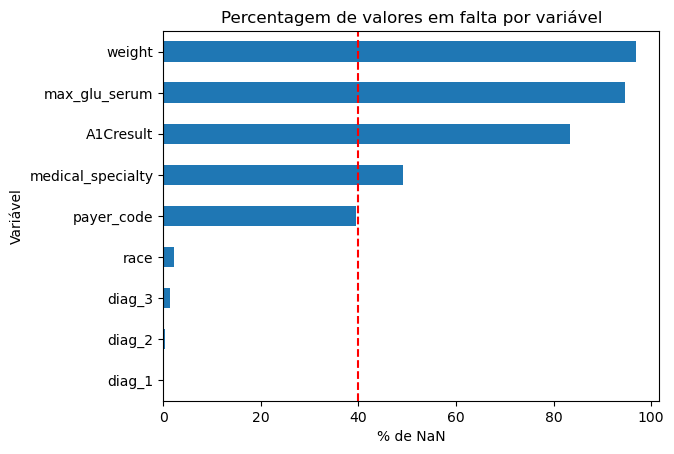

In [36]:
df_nan=df_nan.sort_values("missing_pct", ascending=True)
df_nan["missing_pct"].plot(kind="barh")
plt.title("Percentagem de valores em falta por variável")
plt.xlabel("% de NaN")
plt.ylabel("Variável")
plt.axvline(x=40, color='red', linestyle='--')

**Inspeção da missing Values**

**`weight` (96.86% em falta)**

*Definição clínica:* peso corporal do doente em libras.

*Causa provável do missing:* Pesar doentes em ambiente hospitalar agudo é estruturalmente difícil, exige cama-balança, mobilização do doente, tempo de enfermagem. Em medicina interna típica do período do dataset (1999–2008), não fazia parte do protocolo de admissão sistemático. O missing reflete provavelmente decisões organizacionais (que tipo de unidade pesa) mais do que decisão clínica caso a caso.

*Tipo de missingness:* difícil de classificar com certeza sem dados sobre tipo de unidade. Plausivelmente uma mistura de MAR (depende da unidade, que é variável observada) e MCAR (variação aleatória entre hospitais).

*Tratamento proposto:* descartar a variável dado o nível de ausência (~97%), mas considerar criar uma feature binária `weight_recorded` (1 se medido, 0 caso contrário) que pode capturar o tipo de unidade ou intensidade de cuidados.

**`max_glu_serum` (94.75% em falta) e `A1Cresult` (83.28% em falta)**

*Definição clínica:* `max_glu_serum` indica o intervalo da glicemia sérica máxima medida durante o internamento (`>200`, `>300`, `normal`, `none`). `A1Cresult` indica o intervalo da hemoglobina glicada (`>8`, `>7`, `normal`, `none`). A1c reflete o controlo glicémico médio dos últimos 2-3 meses; glicemia sérica é uma medição pontual.

*Causa provável do missing:* ambos os exames laboratoriais são pedidos por decisão clínica explícita, não realizados sistematicamente. O médico tipicamente solicita-os quando suspeita de descompensação diabética, mau controlo glicémico, ou quando o histórico do doente o justifica. A não-realização não é "esquecimento" , é decisão.

*Tipo de missingness:* MNAR. A decisão de medir é, ela própria, função do estado clínico do doente — *confounding by indication*. Doentes mais complexos têm maior probabilidade de A1c medido e simultaneamente maior risco de readmissão. O facto de "estar em falta" é informação preditiva, não ruído.

*Tratamento proposto:* não imputar nem descartar. Estas variáveis já vêm codificadas com a categoria explícita `none` para "não medido" , tratar como variáveis categóricas normais com 4 níveis. A categoria `none` será a referência ou uma das *dummies*, preservando o sinal informativo da não-medição.

**`medical_specialty` (49.08% em falta)**

*Definição clínica:* especialidade médica do médico que admitiu o doente, com 84 valores distintos (e.g., `Cardiology`, `InternalMedicine`, `Family/GeneralPractice`, `Surgery`).

*Causa provável do missing:* registo administrativo inconsistente entre hospitais. Hospitais maiores com serviços diferenciados tendem a registar especialidade; hospitais menores onde clínicos gerais cobrem múltiplas funções podem omitir o campo.

*Tipo de missingness:* provavelmente MAR, o missing está correlacionado com tipo/dimensão do hospital, que por sua vez correlaciona-se indiretamente com complexidade dos doentes admitidos. Não é um MNAR puro, mas também não é totalmente neutro face ao desfecho. Será confirmado empiricamente na secção seguinte (comparação de taxa de readmissão entre presente vs. ausente).

*Tratamento proposto:* não descartar. Agrupar os 84 valores em poucas categorias clinicamente coerentes (Cirurgia / Medicina Interna / Cardiologia / Família-Geral / Outros / Desconhecido), com `Desconhecido` como categoria explícita preservando o sinal do missing.

**`payer_code` (39.56% em falta)**

*Definição clínica:* tipo de cobertura financeira do internamento, com 23 valores distintos (e.g., `MC` Medicare, `MD` Medicaid, `BC` Blue Cross, `SP` self-pay).

*Causa provável do missing:* registo administrativo inconsistente, alguns hospitais não codificam sistematicamente o pagador no momento da admissão.

*Tipo de missingness:* provavelmente MAR. O missing depende de práticas administrativas hospitalares, não diretamente do desfecho. Mas atenção: se hospitais com pior registo administrativo servirem populações específicas, pode haver correlação indireta com risco de readmissão.

*Tratamento proposto:* agrupar em categorias com significado socioeconómico — `Medicare/Medicaid` (público, doentes mais idosos ou de baixos rendimentos), `Privado` (Blue Cross e equivalentes), `Self-pay` (sem seguro, indicador de vulnerabilidade), `Desconhecido` (missing). Esta variável captura dimensão socioeconómica indireta — acesso a cuidados primários, suporte social, literacia em saúde — que sabidamente influencia readmissão. Manter no modelo, mas marcar para análise de *algorithmic fairness* na fase final: modelos que aprendem este sinal podem perpetuar desigualdades de acesso a cuidados.





## 5. Análise de doentes vs. encontros


## 6. Hipóteses clínicas e exploração de variáveis-chave

**H1 — Idade.** Espero que a taxa de readmissão aumente com a idade, devido à acumulação de comorbilidades, embora não seja o fator dominante.

**H2 — Tempo de internamento.** Tensão entre dois mecanismos opostos: internamentos longos podem indicar maior acompanhamento (efeito protetor) ou maior gravidade (efeito de risco). Possível relação não-linear.

**H3 — Medição de A1c.** A decisão clínica de medir A1c durante o internamento pode ser, ela própria, um sinal de gravidade (confounding by indication) — doentes com A1c medido podem readmitir mais, não menos.

**H4 — Número de medicamentos.** Mais medicamentos refletem polifarmácia e multimorbilidade, com risco acrescido de interações e iatrogenia, prevendo maior readmissão.

**H5 — Visitas prévias (`number_inpatient`, `number_emergency`).** O melhor preditor de evento futuro é evento passado do mesmo tipo — espero forte associação positiva com readmissão.

**H6 — Payer code.** Tipo de seguro pode predizer readmissão indiretamente, refletindo acesso a cuidados primários, suporte social e literacia em saúde — com implicações éticas de fairness a discutir.

## 7. Conclusões da EDA